In [1]:
from transformers import ResNetConfig, ResNetModel

# Initializing a ResNet resnet-50 style configuration
configuration = ResNetConfig()

# Initializing a model (with random weights) from the resnet-50 style configuration
model = ResNetModel(configuration)

# Accessing the model configuration
configuration = model.config

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
Top 3 Predictions:
Book_Jacket: 67.5%
Screen: 3.4%
Packet: 2.5%


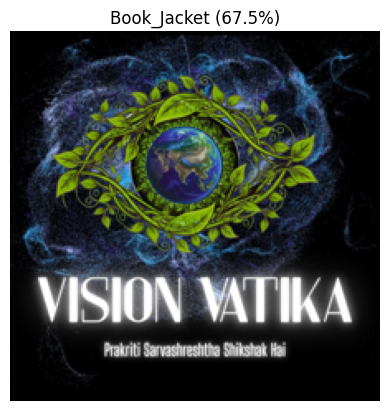

In [8]:
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import img_to_array

# 1. Load the pre-trained ResNet50 model
model = ResNet50(weights='imagenet')

# 2. Download and load a sample image, resizing it to 224x224 (ResNet's required input size)
# url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
img = "Vision Vatika Final Logo.jpg"
img = Image.open(img).resize((224, 224))

# response = requests.get(url)
# img = Image.open(io.BytesIO(response.content)).resize((224, 224))

# 3. Preprocess the image for the model
x = img_to_array(img)
x = np.expand_dims(x, axis=0) # Add the batch dimension
x = preprocess_input(x)       # Applies ImageNet specific color shifting/scaling

# 4. Make the prediction
preds = model.predict(x)

# 5. Decode the results into a list of tuples (class, description, probability)
results = decode_predictions(preds, top=3)[0]

print("Top 3 Predictions:")
for result in results:
    print(f"{result[1].title()}: {100 * result[2]:.1f}%")

# 6. Display the image
plt.imshow(img)
plt.axis('off')
plt.title(f"{results[0][1].title()} ({100 * results[0][2]:.1f}%)")
plt.show()